# Cart Abandonment Prediction — Data Mining
**Dataset:** Retail Rocket · `cart_session_features.csv` (43,917 cart sessions)

**Models:** Logistic Regression · Decision Tree · Random Forest · XGBoost

**Label:** `has_transaction` — 0 = abandoned cart, 1 = purchased

---
## 1. Setup & Load

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    f1_score, precision_score, recall_score, accuracy_score
)
from xgboost import XGBClassifier

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.6,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
PALETTE = ['#1F4E79', '#2E75B6', '#70AD47', '#ED7D31']

print('Libraries loaded.')

Libraries loaded.


In [17]:
df = pd.read_csv('../1-Data/completed-session/cart_session_features.csv')
print(f'Loaded: {len(df):,} sessions  |  columns: {list(df.columns)}')
df.head()

Loaded: 43,917 sessions  |  columns: ['session_key', 'visitorid', 'event_count', 'view_count', 'addtocart_count', 'transaction_count', 'view_to_cart_ratio', 'unique_items_count', 'session_age_seconds', 'inter_event_interval_mean', 'recency_last_cart_seconds', 'has_transaction']


,session_key,visitorid,event_count,view_count,addtocart_count,transaction_count,view_to_cart_ratio,unique_items_count,session_age_seconds,inter_event_interval_mean,recency_last_cart_seconds,has_transaction
0,1000057_3,1000057,3.0,1.0,1.0,1.0,1.0,1.0,494.17,247.084,494.17,1.0
1,100007_1,100007,5.0,3.0,2.0,0.0,1.5,2.0,51.89,12.973,14.36,0.0
2,1000093_1,1000093,6.0,4.0,1.0,1.0,4.0,2.0,1492.99,298.598,1357.73,1.0
3,1000093_4,1000093,4.0,2.0,1.0,1.0,2.0,2.0,387.92,129.308,101.21,1.0
4,1000103_1,1000103,4.0,3.0,1.0,0.0,3.0,2.0,1085.42,361.806,390.78,0.0


---
## 2. Feature Preparation

In [18]:
# Features used for prediction
# transaction_count excluded: logically identical to the label (data leakage)
FEATURES = [
    'view_count',
    'addtocart_count',
    'view_to_cart_ratio',
    'unique_items_count',
    'session_age_seconds',
    'inter_event_interval_mean',
    'recency_last_cart_seconds',
]
TARGET = 'has_transaction'

# recency = -1 means no cart action found; replace with 0 as neutral
df['recency_last_cart_seconds'] = df['recency_last_cart_seconds'].replace(-1, 0)

# Cap extreme outliers at 99th percentile (prevents logistic regression instability)
for f in FEATURES:
    cap = df[f].quantile(0.99)
    df[f] = df[f].clip(upper=cap)

X = df[FEATURES].fillna(0).values
y = df[TARGET].values

print(f'Feature matrix : {X.shape}')
print(f'Class balance  : {y.mean()*100:.1f}% purchased  |  {(1-y.mean())*100:.1f}% abandoned')

Feature matrix : (43917, 7)
Class balance  : 27.2% purchased  |  72.8% abandoned


In [19]:
# 80/20 stratified split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features — required for Logistic Regression, harmless for trees
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train):,}   Test : {len(X_test):,}')
print(f'Train purchase rate : {y_train.mean()*100:.1f}%   Test : {y_test.mean()*100:.1f}%')

Train : 35,133   Test : 8,784
Train purchase rate : 27.2%   Test : 27.2%


---
## 3. Train All Four Models

In [20]:
# ── Model definitions ────────────────────────────────────────────────────────
# class_weight='balanced' compensates for 2.7:1 imbalance without resampling
# (Waldmann et al., 2025 — threshold calibration preferred over SMOTE)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        n_jobs=-1, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss', random_state=42, verbosity=0
    ),
}

print('Models defined:')
for name in models:
    print(f'  {name}')

Models defined:
  Logistic Regression
  Decision Tree
  Random Forest
  XGBoost


In [21]:
# ── Train and evaluate all models ────────────────────────────────────────────
results = {}

for name, model in models.items():
    # Trees use raw features; LR uses scaled
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_prob  = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_prob),
        'y_prob':    y_prob,
    }
    print(f'{name:<22}  AUC={results[name]["auc"]:.4f}  F1={results[name]["f1"]:.4f}')

Logistic Regression     AUC=0.8248  F1=0.5857
Decision Tree           AUC=0.9340  F1=0.7633
Random Forest           AUC=0.9842  F1=0.8886
XGBoost                 AUC=0.9946  F1=0.9355


---
## 4. Results Comparison

In [22]:
# ── Summary table ────────────────────────────────────────────────────────────
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
summary = pd.DataFrame(
    {name: {m: round(results[name][m], 4) for m in metrics} for name in results}
).T
summary.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
print('=== Model Comparison ===')
print(summary.to_string())

=== Model Comparison ===
                     Accuracy  Precision  Recall      F1  AUC-ROC
Logistic Regression    0.7768     0.5908  0.5806  0.5857   0.8248
Decision Tree          0.8414     0.6421  0.9409  0.7633   0.9340
Random Forest          0.9411     0.9145  0.8643  0.8886   0.9842
XGBoost                0.9639     0.9094  0.9631  0.9355   0.9946


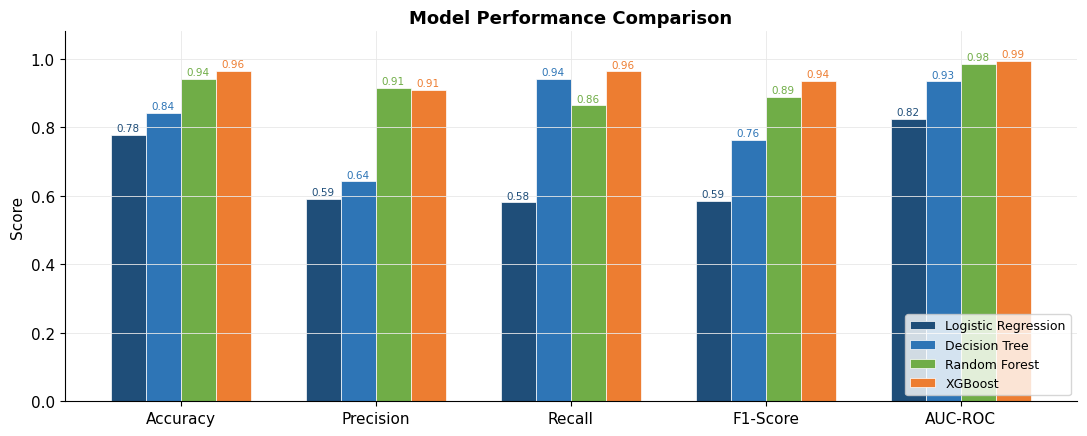

Saved: dm_results_comparison.png


In [23]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

x      = np.arange(len(metrics))
width  = 0.18
names  = list(results.keys())

for i, (name, color) in enumerate(zip(names, PALETTE)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('dm_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dm_results_comparison.png')

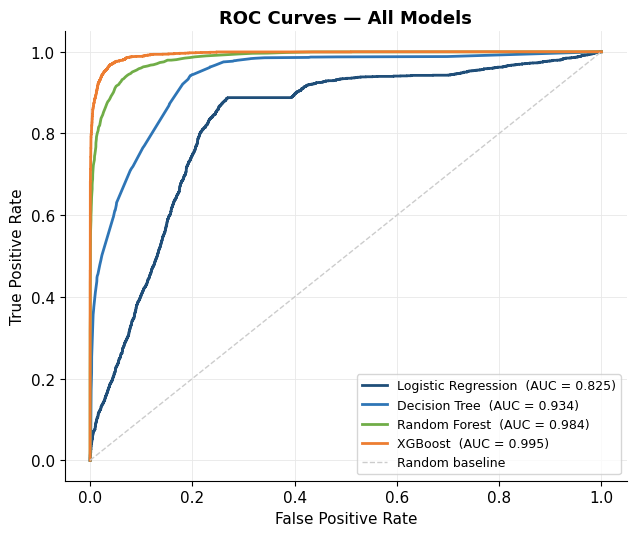

Saved: dm_roc_curves.png


In [24]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for name, color in zip(names, PALETTE):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc_val = results[name]['auc']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], color='#cccccc', linestyle='--',
        linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('dm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dm_roc_curves.png')

---
## 5. Feature Importance

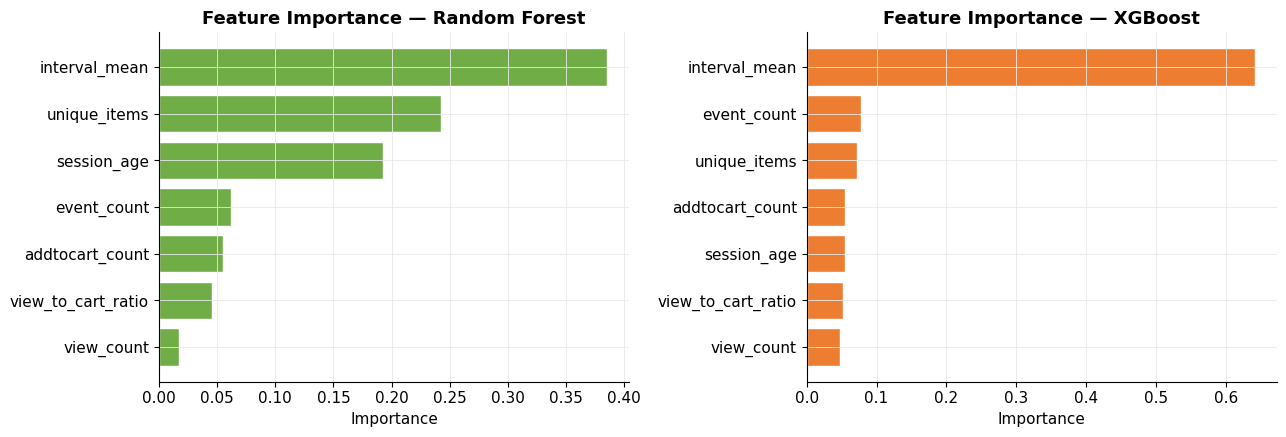

Saved: dm_feature_importance.png


In [25]:
# ── Feature importance: Random Forest + XGBoost side by side ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

feat_labels = [
    'event_count', 'view_count', 'addtocart_count', 'view_to_cart_ratio',
    'unique_items', 'session_age', 'interval_mean', 'recency_cart'
]

for ax, name, color in [
    (axes[0], 'Random Forest', PALETTE[2]),
    (axes[1], 'XGBoost',       PALETTE[3])
]:
    model    = models[name]
    imp      = model.feature_importances_
    order    = np.argsort(imp)
    ax.barh([feat_labels[i] for i in order], imp[order],
            color=color, edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance — {name}')

plt.tight_layout()
plt.savefig('dm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dm_feature_importance.png')

---
## 6. Best Model — Detailed Report

In [26]:
# Best model by AUC
best_name = max(results, key=lambda n: results[n]['auc'])
best_model = models[best_name]
Xte = X_test_sc if best_name == 'Logistic Regression' else X_test

print(f'Best model: {best_name}  (AUC = {results[best_name]["auc"]:.4f})')
print()
print(classification_report(
    y_test,
    best_model.predict(Xte),
    target_names=['Abandoned (0)', 'Purchased (1)']
))

Best model: XGBoost  (AUC = 0.9946)

               precision    recall  f1-score   support

Abandoned (0)       0.99      0.96      0.97      6397
Purchased (1)       0.91      0.96      0.94      2387

     accuracy                           0.96      8784
    macro avg       0.95      0.96      0.96      8784
 weighted avg       0.97      0.96      0.96      8784



In [27]:
# ── Final summary printout ─────────────────────────────────────────────────
print('=== FINAL RESULTS ===')
print(f'{"Model":<22} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AUC":>8}')
print('-' * 70)
for name in names:
    r = results[name]
    print(f'{name:<22} {r["accuracy"]:>9.4f} {r["precision"]:>10.4f} '
          f'{r["recall"]:>8.4f} {r["f1"]:>8.4f} {r["auc"]:>8.4f}')
print()
print('Saved charts: dm_results_comparison.png · dm_roc_curves.png · dm_feature_importance.png')

=== FINAL RESULTS ===
Model                   Accuracy  Precision   Recall       F1      AUC
----------------------------------------------------------------------
Logistic Regression       0.7768     0.5908   0.5806   0.5857   0.8248
Decision Tree             0.8414     0.6421   0.9409   0.7633   0.9340
Random Forest             0.9411     0.9145   0.8643   0.8886   0.9842
XGBoost                   0.9639     0.9094   0.9631   0.9355   0.9946

Saved charts: dm_results_comparison.png · dm_roc_curves.png · dm_feature_importance.png
